In [16]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [6]:
df=('/content/archive (6).zip')

In [ ]:
import zipfile
import os
import tensorflow as tf

In [11]:
import os
import zipfile

zip_file_path = '/content/archive (6).zip'
extract_dir = '/content/dataset'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"Dataset extracted to: {extract_dir}")

Dataset extracted to: /content/dataset


Now that the dataset is extracted, we can load the images using `image_dataset_from_directory`.

In [10]:
import tensorflow as tf

dataset_path = extract_dir

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(128, 128),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(128, 128),
    batch_size=32
)

print("Training and validation datasets created.")

Found 5054 files belonging to 2 classes.
Using 4044 files for training.
Found 5054 files belonging to 2 classes.
Using 1010 files for validation.
Training and validation datasets created.


In [17]:
class_names = train.class_names
print(class_names)

['Garbage classification', 'garbage classification']


In [18]:
normalization_layer = layers.Rescaling(1./255)

train = train.map(lambda x, y: (normalization_layer(x), y))
val = val.map(lambda x, y: (normalization_layer(x), y))

In [19]:
model = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu',
                  input_shape=(128,128,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dense(len(class_names), activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [21]:
history = model.fit(
    train,
    validation_data=val,
    epochs=10
)

Epoch 1/10
127/127 ━━━━━━━━━━━━━━━━━━━━ 130s 1s/step - accuracy: 0.4973 - loss: 0.7114 - val_accuracy: 0.4713 - val_loss: 0.6932
Epoch 2/10
127/127 ━━━━━━━━━━━━━━━━━━━━ 127s 996ms/step - accuracy: 0.5077 - loss: 0.6932 - val_accuracy: 0.4703 - val_loss: 0.6937
Epoch 3/10
127/127 ━━━━━━━━━━━━━━━━━━━━ 127s 999ms/step - accuracy: 0.5074 - loss: 0.6932 - val_accuracy: 0.4703 - val_loss: 0.6940
Epoch 4/10
127/127 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.5074 - loss: 0.6931 - val_accuracy: 0.4703 - val_loss: 0.6940
Epoch 5/10
127/127 ━━━━━━━━━━━━━━━━━━━━ 128s 1s/step - accuracy: 0.5074 - loss: 0.6931 - val_accuracy: 0.4703 - val_loss: 0.6939
Epoch 6/10
127/127 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.5074 - loss: 0.6931 - val_accuracy: 0.4703 - val_loss: 0.6940
Epoch 7/10
127/127 ━━━━━━━━━━━━━━━━━━━━ 127s 999ms/step - accuracy: 0.5074 - loss: 0.6931 - val_accuracy: 0.4703 - val_loss: 0.6939
Epoch 8/10
127/127 ━━━━━━━━━━━━━━━━━━━━ 142s 998ms/step - accuracy: 0.5072 - loss: 0.693

In [22]:
loss, accuracy = model.evaluate(val)

print("Validation Accuracy:", accuracy)

32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 385ms/step - accuracy: 0.4703 - loss: 0.6939
Validation Accuracy: 0.47029703855514526


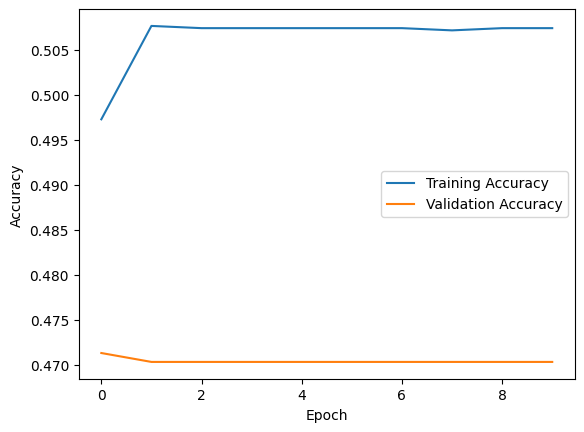

In [23]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [24]:
model.save("garbage_classification_model.h5")